from google.colab import drive
drive.mount('/content/drive')

!rm -r /content/Brain_MRI

!unzip /content/drive/MyDrive/Brain_MRI.zip -d Brain_MRI

!pip install onnxruntime-gpu rembg[gpu] --force-reinstall

!pip install protobuf==3.20.*

# Problem Statement: Build a AI solution to detect brain tumor with explainability (XAI).

## Data Soruce: 
- We have used brain tumor segmentation dataset

## Solution Overview
- A hybrid CNN–Attention U-Net architecture with residual ConvBlocks, Multi-Head Self-Attention (MHSA), and Squeeze-and-Excitation (SE) modules.
- The encoder captures local and global context, while the attention-enhanced decoder refines spatial details using skip connections.
- Joint learning is performed for segmentation (Dice + BCE loss) and classification (softmax), improving feature robustness.
- Evaluation uses Dice coefficient and IoU to handle class imbalance and assess segmentation quality.

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import seaborn as sb
import pandas as pd
import tensorflow as tf
import cv2, json
from PIL import Image
import tensorflow as tf
from tabulate import tabulate
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
from SabreNet import build_model, dice_loss_plus_bce, iou_metric, dice_coefficient
from utils import data_gen
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3060 (UUID: GPU-81f6e2eb-490f-a94c-111c-389f658c4c02)


In [16]:
import cv2, os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
os.makedirs("Report", exist_ok=True)
names = {
        "conv2d_88":   "Shallow CNN Features",
        "conv_block_7": "Encoder Block 1 (Low-level)",
        "conv_block_8": "Encoder Block 2 (Texture)",
        "conv_block_9": "Encoder Block 3 (High-level)",
        "conv_block_10": "Encoder Block 4 (Semantic)",
        "conv_block_11": "Decoder Block 1 (Fusion)",
        "conv_block_12": "Decoder Block 2 (Upsampling)",
        "conv_block_13": "Decoder Block 3 (Localization)",
        "mask_pred":    "Final Prediction",
    }

def skull_strip(img):
    img = cv2.resize(img, [224,224])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ----------------------------
    # 1. Binarize (auto threshold)
    # ----------------------------
    _, binary = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Ensure foreground is white
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    # ----------------------------
    # 2. Morphology to FORCE closure
    # ----------------------------
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    binary_closed = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=3
    )

    binary_closed = cv2.dilate(binary_closed, kernel, iterations=2)

    # ----------------------------
    # 3. Fill holes (guarantees solid object)
    # ----------------------------
    filled = binary_closed.copy()
    h, w = filled.shape
    mask = np.zeros((h + 2, w + 2), np.uint8)

    cv2.floodFill(filled, mask, (0, 0), 255)
    filled = cv2.bitwise_not(filled)
    filled = cv2.bitwise_or(filled, binary_closed)

    # ----------------------------
    # 4. Find ONLY external contours
    # ----------------------------
    contours, _ = cv2.findContours(
        filled,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    assert len(contours) > 0, "No contours found"

    # Largest contour = outer boundary
    outer = max(contours, key=cv2.contourArea)

    # ----------------------------
    # 5. Ensure contour is closed
    # ----------------------------
    if not np.array_equal(outer[0], outer[-1]):
        outer = np.vstack([outer, np.expand_dims(outer[0], 0)])

    # ----------------------------
    # 6. Draw result
    # ----------------------------
    result = img.copy()
#     cv2.drawContours(result, [outer], -1, (0, 0, 255), 2)


    epsilon = 10
    inner_contour = cv2.approxPolyDP(outer, epsilon, True)

    cv2.drawContours(result, [inner_contour], -1, (0, 0, 0), 11)
            
    return result

def overlay_mask_on_image(base_img, mask, color=(255, 0, 0), alpha=0.5):
    """Overlay segmentation mask (binary or soft) on grayscale image."""
    mask = np.array(mask, dtype=np.float32)
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    base = (base_img * 255).astype(np.uint8) if base_img.max() <= 1.0 else base_img.astype(np.uint8)
    if base.ndim == 2:
        base = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    elif base.shape[-1] == 1:
        base = cv2.cvtColor(base[..., 0], cv2.COLOR_GRAY2BGR)

    mask = cv2.resize(mask, (base.shape[1], base.shape[0]), interpolation=cv2.INTER_LINEAR)
    mask = np.clip(mask, 0.0, 1.0)

    mask_colored = np.zeros_like(base, dtype=np.uint8)
    mask_colored[:, :, 0] = color[0]
    mask_colored[:, :, 1] = color[1]
    mask_colored[:, :, 2] = color[2]

    overlay = cv2.addWeighted(base, 1 - alpha, mask_colored, alpha, 0)
    overlay = np.where(mask[..., None] > 0.5, overlay, base)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay


def seg_gradcam_for_layer(model, img_array, layer_name):
    """
    Layer-wise Grad-CAM for segmentation head.
    Backprop from mask_pred to given layer.
    """
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output,
                 model.get_layer("mask_pred").output]
    )

    with tf.GradientTape() as tape:
        feats, mask_out = grad_model(img_array, training=False)
        # scalar loss: mean log probability of predicted mask
        loss = tf.reduce_mean(tf.math.log(mask_out + 1e-6))

    grads = tape.gradient(loss, feats)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}")

    # Global average pooling over spatial dims
    weights = tf.reduce_mean(grads[0], axis=(0, 1))         # (C,)
    cam = tf.reduce_sum(feats[0] * weights, axis=-1)        # (H,W)
    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)
    return cam


def plot_layer_gradcam(base_img, cam, layer_name):
    # Resize CAM to input size
    cam_resized = cv2.resize(cam, (base_img.shape[1], base_img.shape[0]), interpolation=cv2.INTER_LINEAR)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

    base = (base_img * 255).astype(np.uint8) if base_img.max() <= 1.0 else base_img.astype(np.uint8)
    if base.ndim == 2:
        base = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    elif base.shape[-1] == 1:
        base = cv2.cvtColor(base[..., 0], cv2.COLOR_GRAY2BGR)

    overlayed = cv2.addWeighted(base, 0.5, heatmap, 0.5, 0)
    overlayed = cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlayed)
    plt.title(f"{names.get(layer_name, layer_name)}")
    plt.axis("off")
    save_path = f"Report/{names.get(layer_name, layer_name)}.png"
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1)
    plt.show()


def plot_gradcam(img, model, plot = True):
    
    feature_layers = [
    l for l in model.layers
    if hasattr(l, "output_shape")
    and len(l.output_shape) == 4
    and ("block" in l.name or "reshape_back" in l.name)
    ]

    layers = [l.name for l in feature_layers]
    
    for lname in layers:
        names.setdefault(lname, lname)

    if any(l.name == "mask_pred" for l in model.layers):
        layers.append("mask_pred")

    layers = list(dict.fromkeys(layers))
    
    img_org = img.copy()
    img = skull_strip(img)
    # img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)/255
    img = np.expand_dims(img, -1)
    Xb = np.expand_dims(img, 0)
    img = np.squeeze(img)

    # Dual-output model: (mask_pred, cls_pred)
    mask_pred, cls_pred = model.predict(Xb, verbose=0)
    mask_pred = np.array(mask_pred[0, :, :, 0], dtype=np.float32)
    cls_pred = np.array(cls_pred[0], dtype=np.float32)

    cls_label = int(np.argmax(cls_pred))
    cls_prob = float(np.max(cls_pred))

#     overlay_img = overlay_mask_on_image(img_org, mask_pred, color=(255, 0, 0), alpha=0.5)
#     plt.figure(figsize=(6, 6))
#     plt.imshow(overlay_img)
#     plt.title(f"Predicted Tumor Region (Class {cls_label}, p={cls_prob:.2f})")
#     plt.axis("off")
#     plt.savefig("Report/Predicted Mask Overlay.png", bbox_inches="tight", pad_inches=0.1)
#     plt.show()

    grads = []
    for layer_name in layers:
        try:
            cam = seg_gradcam_for_layer(model, Xb, layer_name)
            
            if "mhsa" in layer_name:
                im = (cam*255).astype("uint8")
                im = cv2.resize(im, (224, 224))
                grads.append(im)
            
            if plot:
                plot_layer_gradcam(img_org, cam, layer_name)

        except Exception as e:
            print(f"Skipped {layer_name} due to: {e}")
    return grads

In [3]:
files = glob.glob('dataset/Segmentation/*/*')

In [4]:
lab = {'glioma' : 0, 'meningioma' : 1, 'pituitary' : 2}
rev_lab = dict(zip(lab.values(), lab.keys()))

In [5]:
image_path = [files[i] for i in range(0, len(files), 2)]
mask_path = [files[i] for i in range(1, len(files), 2)]

df = pd.DataFrame.from_dict({"image_path" : image_path, "mask_path" : mask_path})

df["label"] = df["image_path"].str.lower().str.split("\\").str[1]

df['label'] = df['label'].apply(lab.get)

df

,image_path,mask_path,label
0,dataset/Segmentation\Glioma\enh_1841.png,dataset/Segmentation\Glioma\enh_1841_mask.png,0
1,dataset/Segmentation\Glioma\enh_1842.png,dataset/Segmentation\Glioma\enh_1842_mask.png,0
2,dataset/Segmentation\Glioma\enh_1843.png,dataset/Segmentation\Glioma\enh_1843_mask.png,0
3,dataset/Segmentation\Glioma\enh_1844.png,dataset/Segmentation\Glioma\enh_1844_mask.png,0
4,dataset/Segmentation\Glioma\enh_1845.png,dataset/Segmentation\Glioma\enh_1845_mask.png,0
...,...,...,...
2187,dataset/Segmentation\Pituitary\enh_995.png,dataset/Segmentation\Pituitary\enh_995_mask.png,2
2188,dataset/Segmentation\Pituitary\enh_996.png,dataset/Segmentation\Pituitary\enh_996_mask.png,2
2189,dataset/Segmentation\Pituitary\enh_997.png,dataset/Segmentation\Pituitary\enh_997_mask.png,2
2190,dataset/Segmentation\Pituitary\enh_998.png,dataset/Segmentation\Pituitary\enh_998_mask.png,2


In [6]:
train_df, val_df  = train_test_split(df, test_size=0.20, random_state=100, stratify=df['label'])

In [7]:
len(train_df), len(val_df)

(1753, 439)

# CNN + Multi-Head Self-Attention

In [11]:
model = build_model(input_shape=(224,224,1), num_classes=3)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = .0001),
    loss={'mask_pred': dice_loss_plus_bce,#bce_dice_loss,
          'classifier': 'categorical_crossentropy'
         },
    metrics={'mask_pred': [dice_coefficient, iou_metric],
             'classifier': ['accuracy']}
)

In [12]:
model.load_weights('BT_CLF_Attention.h5')

GT:  glioma
Pred: glioma (1.0)


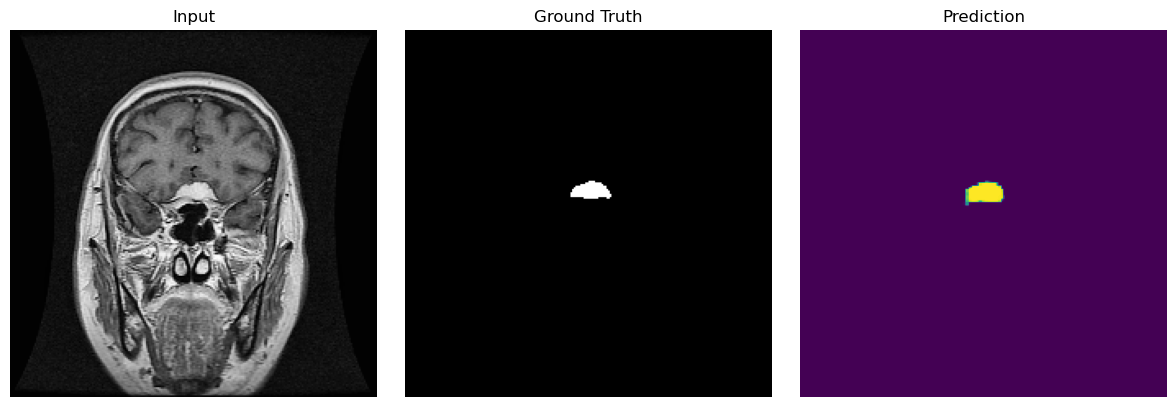

In [15]:
sampx, sampy1 = next(data_gen(val_df, 3))
sampy1, sampy2 = sampy1

idx = 2

img = sampx[idx]

im = (img*255).astype("uint8")
im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)

gt_cls = rev_lab.get(np.argmax(sampy2[idx]))
gt_mask = sampy1[idx]
print("GT: ", gt_cls)

res = model.predict(np.expand_dims(img, 0), verbose=False)
seg = res[0][0]

print(f"Pred: {rev_lab.get(np.argmax(res[1]))} ({np.max(res[1])})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(seg)
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [17]:
gradcams_org = plot_gradcam(im, model, False)

In [18]:
def normalize_map(x, eps=1e-8):
    x = x - tf.reduce_min(x)
    return x / (tf.reduce_max(x) + eps)

def tumor_score(pred_map):
    # scalar target
    return tf.reduce_sum(pred_map)

### Notation

- Input image:
  $$x \in \mathbb{R}^{H \times W \times C}$$

- Attribution map:
  $$A \in \mathbb{R}^{H \times W}, \quad A \ge 0$$

- Model output (segmentation probability map):
  $$f(x) \in \mathbb{R}^{H \times W}$$

- Scalar model confidence score:
  $$S(x) = \sum_{i,j} f(x)_{i,j}$$

- Pixels sorted by attribution (descending):
  $$\pi = \text{argsort}(A, \text{desc})$$

- Baseline image (blurred or mean image):
  $$x_{\text{base}}$$

- Number of perturbation steps:
  $$K$$


### Deletion

Deletion measures how quickly the model confidence decreases when the most
important pixels (according to the attribution map) are removed.

Let $x^{(k)}$ denote the image obtained by replacing the top-$k$ attributed
pixels with a baseline image $x_{\text{base}}$.

$$
\text{Deletion}
=
1 - \frac{1}{K} \sum_{k=0}^{K}
\frac{S(x^{(k)})}{S(x)}
$$

**Interpretation:**
- Higher values indicate that removing important pixels rapidly degrades
  the model prediction.
- Lower values indicate weak or non-causal attributions.


In [20]:
def deletion_auc(model, image, attr, steps=30):
    H, W, _ = image.shape
    attr = normalize_map(attr)

    flat_attr = tf.reshape(attr, [-1])
    idx = tf.argsort(flat_attr, direction="DESCENDING")

    baseline = tf.nn.avg_pool2d(
        tf.expand_dims(image, 0),
        ksize=11,
        strides=1,
        padding="SAME"
    )[0]

    scores = []
    for i in range(steps + 1):
        k = int(i / steps * H * W)
        mask_idx = idx[:k]

        mask = tf.scatter_nd(
            tf.expand_dims(mask_idx, 1),
            tf.ones_like(mask_idx, tf.float64),
            [H * W]
        )
        mask = tf.reshape(mask, (H, W, 1))

        perturbed = image * (1 - mask) + baseline * mask
        pred = model(tf.expand_dims(perturbed, 0))[0][0]
        scores.append(tumor_score(pred))

    scores = tf.stack(scores)
    auc = tf.reduce_mean(scores)
    return 1.0 - auc / tf.reduce_max(scores)

### Insertion

Insertion measures how quickly the model confidence increases when the most
important pixels are gradually added back into a baseline image.

Let $x^{(k)}$ denote the image obtained by inserting the top-$k$ attributed
pixels into $x_{\text{base}}$.

$$
\text{Insertion}
=
\frac{1}{K} \sum_{k=0}^{K}
\frac{S(x^{(k)})}{S(x)}
$$

**Interpretation:**
- Higher values indicate that adding attributed pixels increases confidence.
- High insertion alone does not guarantee a correct explanation.


In [21]:
def insertion_auc(model, image, attr, steps=30):
    H, W, _ = image.shape
    attr = normalize_map(attr)

    flat_attr = tf.reshape(attr, [-1])
    idx = tf.argsort(flat_attr, direction="DESCENDING")

    img = tf.nn.avg_pool2d(
        tf.expand_dims(image, 0),
        ksize=11,
        strides=1,
        padding="SAME"
    )[0]

    scores = []
    for i in range(steps + 1):
        k = int(i / steps * H * W)
        mask_idx = idx[:k]

        mask = tf.scatter_nd(
            tf.expand_dims(mask_idx, 1),
            tf.ones_like(mask_idx, tf.float64),
            [H * W]
        )
        mask = tf.reshape(mask, (H, W, 1))

        img = img * (1 - mask) + image * mask
        pred = model(tf.expand_dims(img, 0))[0]
        scores.append(tumor_score(pred))

    scores = tf.stack(scores)
    auc = tf.reduce_mean(scores)
    return auc / tf.reduce_max(scores)

### Infidelity

Infidelity quantifies how well the attribution map predicts changes in the
model output under random perturbations.

Let $\delta$ be a random perturbation mask.

$$
\text{Infidelity}(A)
=
\mathbb{E}_{\delta}
\left[
\left(
\langle A, \delta \rangle
-
\left(S(x) - S(x - \delta)\right)
\right)^2
\right]
$$

We report a normalized score in the range $[0,1]$:

$$
\text{Infidelity}_{\text{score}}
=
\frac{1}{1 + \text{Infidelity}(A)}
$$

**Interpretation:**
- Higher values indicate better alignment between attribution and output
  change.
- Measures consistency, not selectivity.


In [22]:
def infidelity(model, image, attr, n_samples=20, noise_std=0.2):
    attr = normalize_map(attr)

    base_pred = model(tf.expand_dims(image, 0))[0]
    base_score = tumor_score(base_pred)

    errors = []
    for _ in range(n_samples):
        noise = tf.random.normal(image.shape, stddev=noise_std, dtype=tf.float64)
        perturbed = image + noise

        pert_pred = model(tf.expand_dims(perturbed, 0))[0]
        delta = tf.cast(base_score - tumor_score(pert_pred), dtype= tf.float64)

        attr_effect = tf.reduce_sum(attr * tf.reduce_mean(noise, axis=-1))
        
        errors.append((attr_effect - delta) ** 2)

    infid = tf.reduce_mean(errors)
    return 1.0 / (1.0 + infid)

### Sparsity

Sparsity measures how concentrated the attribution map is over pixels.

First, normalize the attribution map into a probability distribution:

$$
p_{i,j} = \frac{A_{i,j}}{\sum_{m,n} A_{m,n}}
$$

Compute the entropy:

$$
H(A) = - \sum_{i,j} p_{i,j} \log(p_{i,j})
$$

Normalize by the maximum possible entropy:

$$
H_{\max} = \log(H \cdot W)
$$

The sparsity score is defined as:

$$
\text{Sparsity} = 1 - \frac{H(A)}{H_{\max}}
$$

**Interpretation:**
- Higher values indicate more focused explanations.
- Lower values indicate diffuse explanations.


In [23]:
def sparsity(attr, k=0.1):
    attr = normalize_map(attr)
    flat = tf.reshape(attr, [-1])

    n = tf.size(flat)
    k_idx = tf.cast(k * tf.cast(n, tf.float32), tf.int32)
    k_idx = tf.maximum(k_idx, 1)

    values, _ = tf.math.top_k(flat, k=k_idx)
    thresh = values[-1]

    mask = tf.cast(attr >= thresh, tf.float64)
    return tf.reduce_sum(mask) / tf.cast(n, tf.float64)

In [26]:
gradcams = tf.cast(gradcams_org, dtype=tf.float64)/255

best_idx = tf.argmax([
    deletion_auc(model, tf.cast(img, tf.float64), a)
    for a in gradcams
])

gradcams = gradcams[best_idx]

deletion_score = deletion_auc(model, tf.cast(img, tf.float64), gradcams)

insertion_score = insertion_auc(model, tf.cast(img, tf.float64), gradcams)

infidelity_score = infidelity(model, tf.cast(img, tf.float64), gradcams)

sparsity_score = sparsity(gradcams)

headers = ["Metrics", "Score"]
rows = [
    ["Deletetion", deletion_score],
    ["Insertion", insertion_score],
    ["Infidelity", infidelity_score],
    ["Sparsity", sparsity_score],
]

print(tabulate(rows, headers=headers, tablefmt='fancy_grid'))


╒════════════╤═════════════╕
│ Metrics    │       Score │
╞════════════╪═════════════╡
│ Deletetion │ 0.706187    │
├────────────┼─────────────┤
│ Insertion  │ 0.613607    │
├────────────┼─────────────┤
│ Infidelity │ 2.14236e-05 │
├────────────┼─────────────┤
│ Sparsity   │ 0.104552    │
╘════════════╧═════════════╛


In [30]:
def xai_quality(deletion, insertion):
    if deletion > 0.7 and insertion < 0.65:
        return "Good explanation"
    if deletion < 0.6 and insertion > deletion:
        return "Unreliable / Failure"
    return "Ambiguous"
xai_quality(deletion_score, insertion_score)

'Good explanation'

# Notes
All scores are normalized to the range $[0,1]$.

Higher values indicate better explanations for Deletion, Insertion,
Infidelity score, and Sparsity.

Deletion is the primary causal metric; others provide supporting evidence.

# Why we focus on Deletion and Insertion

Among the evaluated XAI metrics, **Deletion** and **Insertion** are retained as the
primary evaluation criteria because they directly test the *causal relationship*
between the attribution map and the model prediction.

- **Deletion** measures how quickly the model’s confidence deteriorates when the
  most-attributed pixels are removed. A strong drop indicates that the explanation
  captures information the model truly relies on.

- **Insertion** measures how quickly confidence increases when attributed pixels
  are added back. When interpreted together with Deletion, it helps distinguish
  faithful explanations from diffuse or misleading ones.

The other metrics are not used as primary decision criteria:

- **Infidelity** mainly measures internal consistency between attribution and
  output change, but does not penalize spatial diffusion. In practice, both correct
  and incorrect explanations can achieve similarly low infidelity scores.

- **Sparsity** describes how concentrated an explanation is, but attention maps are
  inherently smooth and low-frequency. As a result, sparsity values do not reliably
  separate good explanations from failure cases.

Therefore, we prioritize **Deletion** (causality) and **Insertion** (supporting
evidence) as they provide the most reliable and discriminative signals for
faithfulness-based XAI in the absence of ground-truth explanations.


In [ ]:
# 1 good Case

# Deletetion -> 0.8604393005371094
# Insertion -> 0.41986769437789917
# Infidelity -> 5.263292805908223e-06
# Sparsity -> 0.10269850127551021


# 2 Failure Case (Explicit-Full cover)

# Deletetion -> 0.672437310218811
# Insertion -> 0.6298398971557617
# Infidelity -> 7.768843211766213e-06
# Sparsity -> 0.10142299107142858

# 3 Wrong-prediction

# Deletetion -> 0.45118796825408936
# Insertion -> 0.7141979932785034
# Infidelity -> 4.30144447158021e-06
# Sparsity -> 0.10182158801020408
